notebooks/04_forecasting.py
============================
Sales forecasting with SARIMAX and seasonal decomposition.

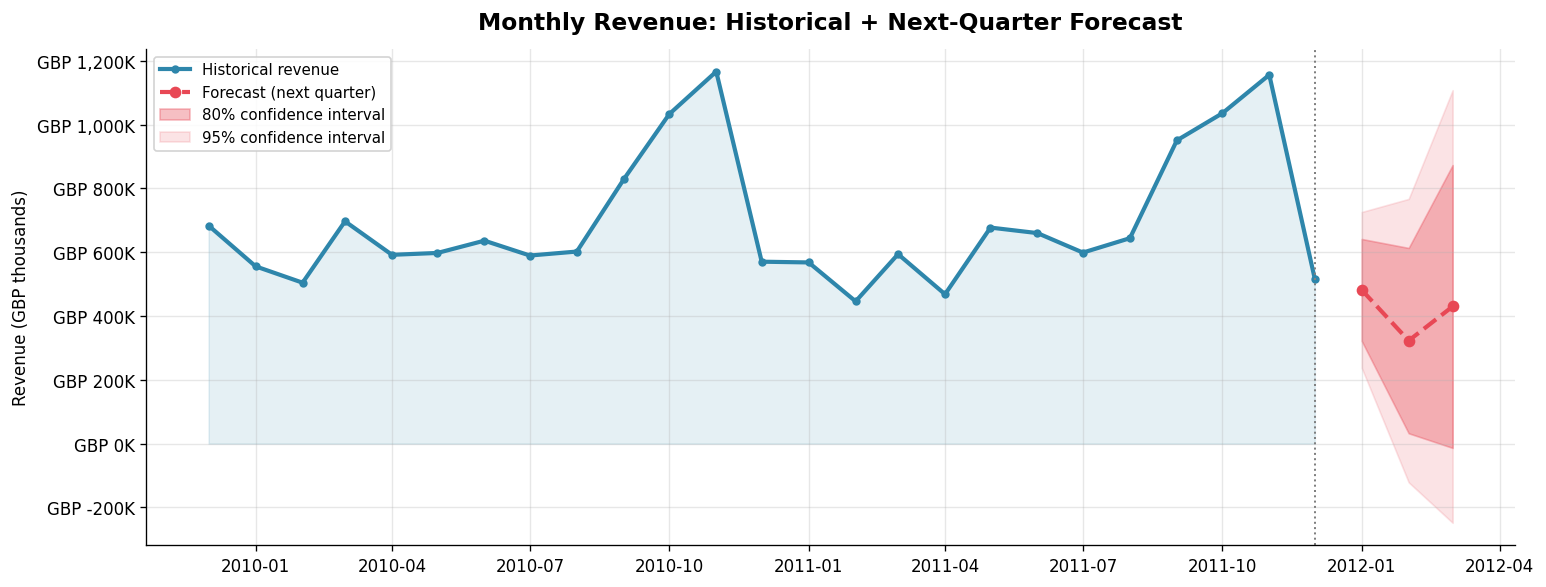

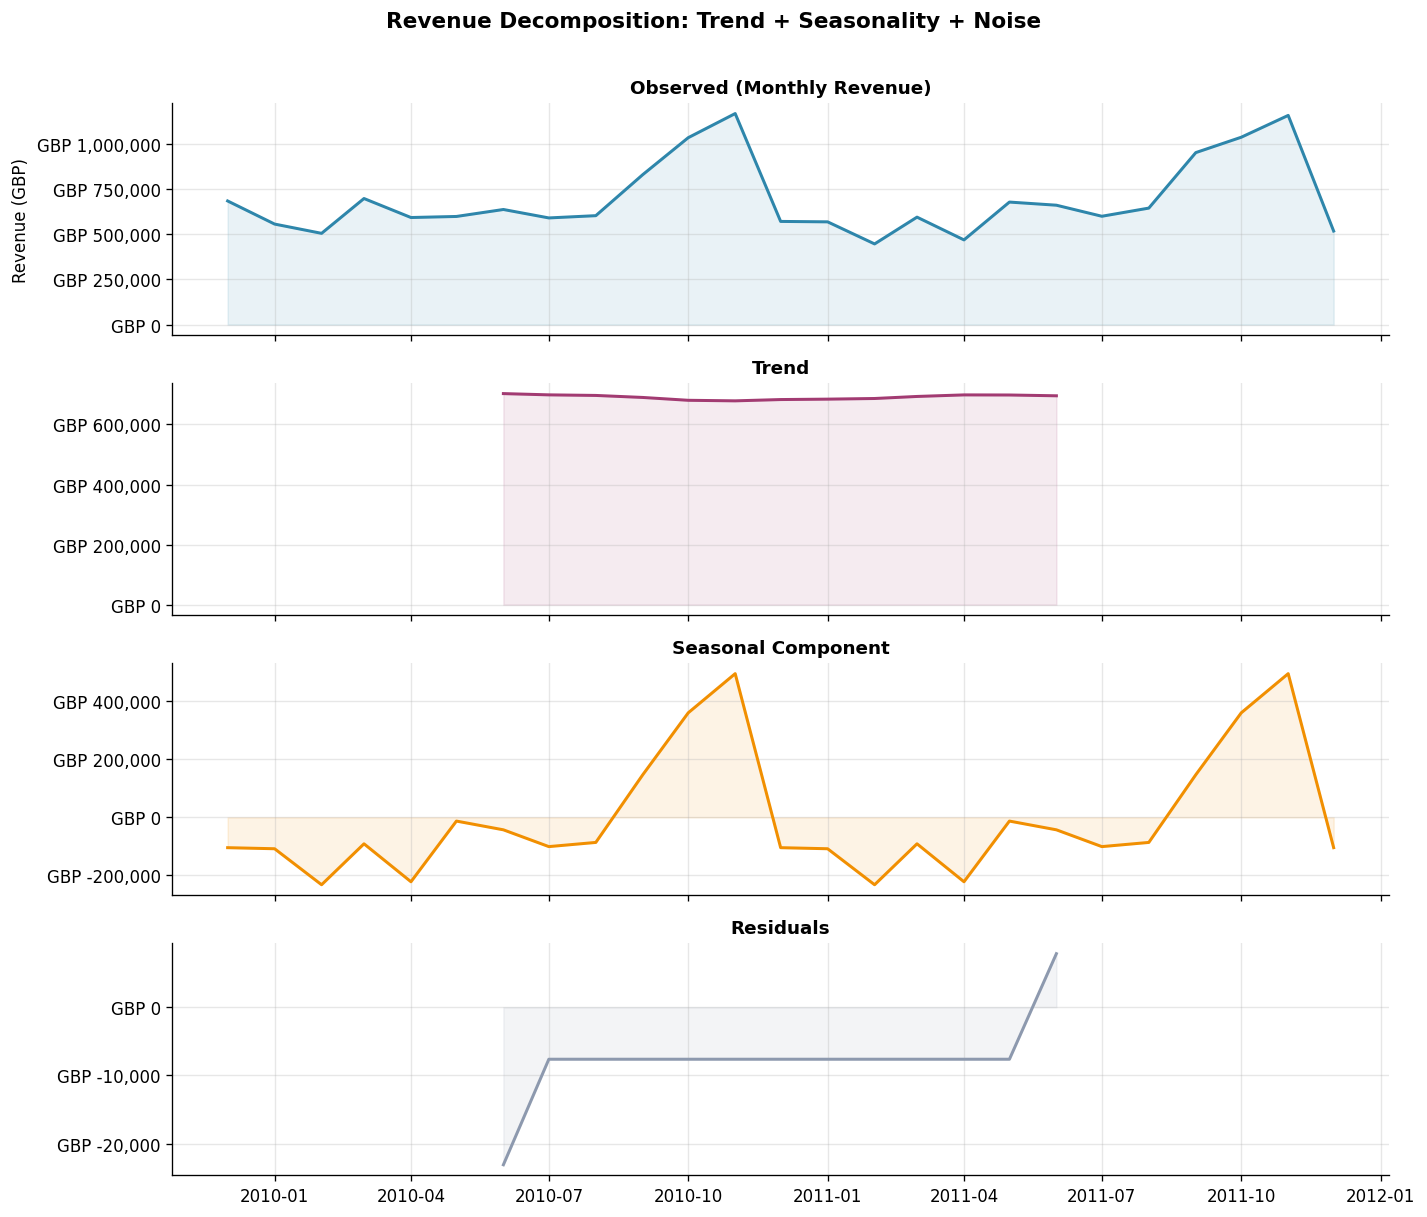

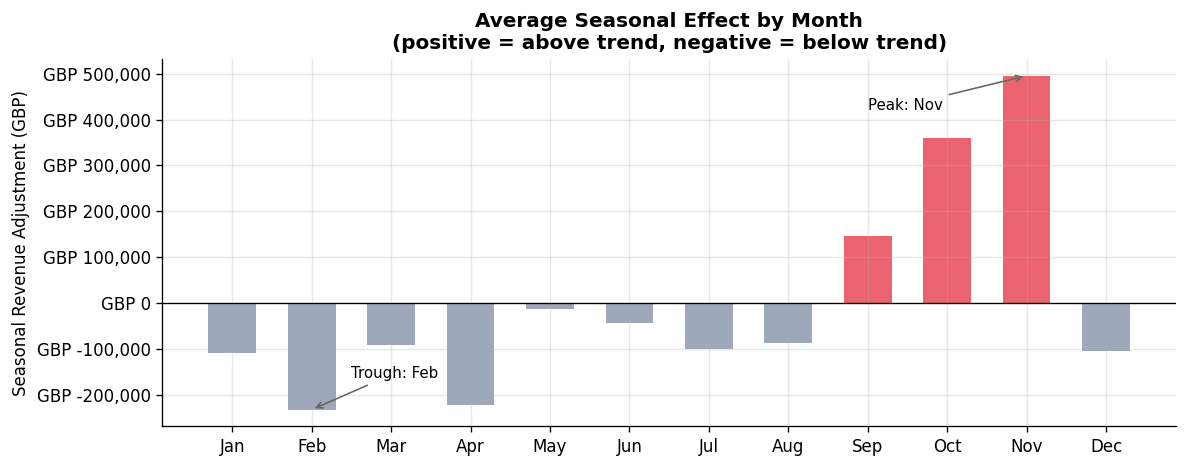

In [ ]:
import sys, os, matplotlib
matplotlib.use('Agg')
from pathlib import Path
_PROJECT_ROOT = Path(__file__).resolve().parent.parent
sys.path.insert(0, str(_PROJECT_ROOT))
os.chdir(_PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.family": "sans-serif",
})
PALETTE = "#2E86AB"
FIGURES_DIR = _PROJECT_ROOT / "data" / "processed" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

from src.data_cleaning import load_cleaned
from src.forecasting import run_forecasting_pipeline, build_monthly_revenue

df = load_cleaned()
forecast_df, fitted_model, decomp = run_forecasting_pipeline(df)
monthly = build_monthly_revenue(df)

# ── Chart 1: Historical + Forecast with confidence intervals ─────────────────
hist = forecast_df[forecast_df["type"] == "Historical"]
fcast = forecast_df[forecast_df["type"] == "Forecast"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(hist["date"], hist["revenue"] / 1000, alpha=0.12, color=PALETTE)
ax.plot(hist["date"], hist["revenue"] / 1000, color=PALETTE, linewidth=2.5,
        marker="o", markersize=4, label="Historical revenue")

# Forecast line + confidence bands
ax.plot(fcast["date"], fcast["forecast_mean"] / 1000, color="#E84855",
        linewidth=2.5, marker="o", markersize=6, linestyle="--", label="Forecast (next quarter)")
ax.fill_between(fcast["date"],
                fcast["lower_80"] / 1000, fcast["upper_80"] / 1000,
                alpha=0.35, color="#E84855", label="80% confidence interval")
ax.fill_between(fcast["date"],
                fcast["lower_95"] / 1000, fcast["upper_95"] / 1000,
                alpha=0.15, color="#E84855", label="95% confidence interval")

ax.set_title("Monthly Revenue: Historical + Next-Quarter Forecast", fontsize=14,
             fontweight="bold", pad=12)
ax.set_ylabel("Revenue (GBP thousands)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"GBP {x:,.0f}K"))
ax.legend(loc="upper left", fontsize=9, framealpha=0.85)
ax.axvline(x=hist["date"].iloc[-1], color="gray", linestyle=":", linewidth=1.2,
           label="Forecast start")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_revenue_forecast.png", bbox_inches="tight")
plt.close()
print("Saved: 11_revenue_forecast.png")

# ── Chart 2: Seasonal decomposition ─────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

components = [
    (monthly.values, "Observed (Monthly Revenue)", PALETTE),
    (decomp.trend, "Trend", "#A23B72"),
    (decomp.seasonal, "Seasonal Component", "#F18F01"),
    (decomp.resid, "Residuals", "#8D99AE"),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(monthly.index, data, color=color, linewidth=1.8)
    ax.fill_between(monthly.index, data, alpha=0.1, color=color)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"GBP {x:,.0f}"))

axes[0].set_ylabel("Revenue (GBP)")
plt.suptitle("Revenue Decomposition: Trend + Seasonality + Noise", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_seasonal_decomposition.png", bbox_inches="tight")
plt.close()
print("Saved: 12_seasonal_decomposition.png")

# ── Chart 3: Average seasonal pattern (month-by-month) ───────────────────────
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
seasonal_by_month = pd.Series(decomp.seasonal).groupby(
    pd.DatetimeIndex(monthly.index).month
).mean()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#E84855" if s > 0 else "#8D99AE" for s in seasonal_by_month.values]
ax.bar(month_names, seasonal_by_month.values, color=colors, alpha=0.85, width=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Average Seasonal Effect by Month\n(positive = above trend, negative = below trend)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Seasonal Revenue Adjustment (GBP)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"GBP {x:,.0f}"))

# Annotate peak and trough
peak_idx = seasonal_by_month.idxmax() - 1
trough_idx = seasonal_by_month.idxmin() - 1
ax.annotate(f"Peak: {month_names[peak_idx]}", xy=(peak_idx, seasonal_by_month.max()),
            xytext=(peak_idx - 2, seasonal_by_month.max() * 0.85),
            arrowprops=dict(arrowstyle="->", color="dimgray"), fontsize=9)
ax.annotate(f"Trough: {month_names[trough_idx]}", xy=(trough_idx, seasonal_by_month.min()),
            xytext=(trough_idx + 0.5, seasonal_by_month.min() * 0.7),
            arrowprops=dict(arrowstyle="->", color="dimgray"), fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "13_seasonal_pattern.png", bbox_inches="tight")
plt.close()
print("Saved: 13_seasonal_pattern.png")

print("\nForecasting notebook complete.")